# Lexos API ClusterMap Tutorial: Visualizing Document-Term Relationships

Welcome to this tutorial on using the Lexos API to generate a ClusterMap! A ClusterMap is a powerful visualization that combines a heatmap with dendrograms (tree diagrams) to help you explore and understand the intricate relationships between your documents and the terms (words) they contain.

Unlike a simple dendrogram that only clusters documents, a ClusterMap allows you to simultaneously cluster both your documents and the terms within them. This provides a rich, two-dimensional view of where specific words are concentrated across your texts and how those concentrations lead to natural groupings.

In this notebook, we'll walk through each step, explaining the "why" behind the "how" in a way that's clear and helpful for literary analysis. Let's get started!

### 1. Setting Up Your Environment: The Essential Tools

Before we dive into analyzing texts, we need to make sure you have the necessary "tools" installed on your computer. These are software libraries that `lexos` relies on to do its work.

**Important:** These commands need to be run in your **command line** (also known as your terminal or console), not directly in this Jupyter Notebook. Open your command line program and type these commands, pressing Enter after each one:


### 2. Loading Our Libraries: Getting Ready to Work

Now that the tools are installed, let's load them into our Jupyter Notebook environment. Think of this as opening up your toolbox and laying out all the instruments you'll need for your analysis.

Run the following code cell:

In [1]:
import spacy
import matplotlib.pyplot as plt
import seaborn as sns # We'll use seaborn for its plotting capabilities
import pandas as pd   # pandas is crucial for handling tabular data like our DTM

from lexos.dtm import DTM
from lexos.cluster.clustermap import ClusterMap

# Load the English language model for spaCy.
# This makes the 'nlp' object ready to process English text.
nlp = spacy.load("en_core_web_sm")

nlp.max_length = 1200000 # Set a new limit slightly above your text's length, in our case, it is 1110000

# Set a consistent theme for seaborn plots
sns.set_theme()

### 3. Gathering Our Texts: The Documents for Analysis

Next, we need to tell `lexos` which text files we want to analyze. For this tutorial, we'll use a few classic literary works as examples. We'll store their locations in a Python dictionary.

A **dictionary** is like a list where each item has a unique **label** (like "Poe" or "Irving") that helps us find its corresponding **value** (the actual path to the text file on your computer). These labels will become the names of your documents in the final clustermap.

**Important Note for Your Own Texts:** If you replace these example files with your own custom texts, please be aware that `spaCy` (the text processing library) has a default safety limit of **1,000,000 characters** per document. Very, very long documents might need special handling, but for most literary works, this limit is generous.

**Before running this cell, make sure the file paths are correct for where you've saved these example texts on your computer!** If you move this Jupyter Notebook, you might need to adjust the paths to point to the correct locations.

In [ ]:
from pathlib import Path

# Load text files from uploaded documents.
# The 'key' (e.g., "Poe") will be our document label.
# The 'value' is the path to the text file.
files = {
    "AI1": "FilesToUse/AI_The_Hermit.txt",
    "AI2": "FilesToUse/AI_The_Invention.txt",
    "Henry": "FilesToUse/HenryWP_ThePirate_Short.txt",
}

# Read the content of each text file into a list of strings
docs = [Path(path).read_text(encoding="utf-8") for path in files.values()]

# Get the labels (names) for each document directly from our dictionary's keys
labels = list(files.keys())

print(f"Loaded {len(docs)} documents with labels: {labels}")

Loaded 3 documents with labels: ['AI1', 'AI2', 'Henry']


### 4. Creating the Document-Term Matrix (DTM): Our Linguistic "Spreadsheet"

Just like with the Bootstrap Consensus Tree, the **Document-Term Matrix (DTM)** is the crucial first step. It transforms your raw text documents into a structured numerical format.

Imagine a giant spreadsheet (a matrix) where:
* Each **row** represents one of your documents (e.g., "Poe_Usher", "Irving_Rip").
* Each **column** represents a unique "term" (usually a word) found across all your documents.
* Each **cell** contains a number indicating how many times that specific "term" appears in that specific document.

This matrix is the foundation for analyzing textual relationships.

#### What is a "Term" and How Do We Prepare Our Texts?

In this context, a "term" is typically a word. However, before counting words, `lexos` (using `spaCy` behind the scenes) performs several crucial **pre-processing** steps. These steps clean and standardize your text, ensuring that the counts are meaningful for analysis.

Here are some important pre-processing options you can control when creating the DTM:

* **`stop_words`**: These are very common words (like 'a', 'an', 'the', 'is', 'and', 'but') that appear frequently in almost all texts and often don't carry much unique meaning for distinguishing between documents.
    * **`True` (default)**: Removes these common words.
    * **`False`**: Keeps all words.
    * *Why use it?* Removing stop words helps you focus on the more distinctive vocabulary that truly characterizes your texts.

* **`lemmatize`**: This reduces words to their **base form** (their "lemma"). For example, 'running', 'ran', and 'runs' would all become 'run'.
    * **`True`**: Words are lemmatized.
    * **`False` (default)**: Words are not lemmatized.
    * *Why use it?* If you want to analyze concepts regardless of their grammatical variations, lemmatization is very useful. For instance, focusing on the concept of "fear" rather than distinguishing between "fear," "fears," and "feared."

* **`pos_filter`**: This allows you to include only terms that are specific **Parts-of-Speech (POS)**, like nouns, verbs, adjectives, etc.
    * You provide a list of desired POS tags (e.g., `['NOUN', 'VERB', 'ADJ']`).
    * *Why use it?* If you're interested in how documents relate based only on the **objects** they discuss (nouns), the **actions** they describe (verbs), or the **qualities** they assign (adjectives), this filter is incredibly powerful.

* **`min_freq` / `max_freq`**: These settings control the frequency of terms included in the DTM.
    * **`min_freq`**: The minimum number of times a term must appear *across all documents* to be included. Setting `min_freq=2` would remove unique misspellings or rare words that might not be significant.
    * **`max_freq`**: The maximum proportion of documents a term can appear in. Setting `max_freq=0.8` (0.8 or 80%) would remove terms that appear in almost every document, acting almost like custom stop words for your specific dataset.
    * *Why use them?* To focus on terms that are neither too rare (potentially noise) nor too common (not distinctive).

* **`ngrams`**: This allows you to treat **phrases** (sequences of words) as single "terms" in your DTM, rather than just individual words.
    * You provide a tuple like `(1, 2)`: `1` includes single words (unigrams), and `2` includes two-word phrases (bigrams). `(2, 3)` would include two- and three-word phrases.
    * *Why use it?* Captures collocations and common phrases that might carry more meaning than individual words (e.g., "dark forest" vs. "dark" and "forest" separately).

#### Creating Our DTM

Let's create our DTM. In this example, we'll start with the default settings for `stop_words` and `lemmatize`. We'll use `nlp(doc)` to first process each raw text string into a `spaCy` document object.


In [12]:
# Cell 10 (Code Cell - MODIFIED AGAIN, removing potentially problematic .T)

# Create an instance of the DTM object
dtm = DTM()

# Process our documents with spaCy and then create the DTM.
dtm(
    docs=[nlp(doc) for doc in docs],
    labels=labels,
)

print(f"DTM created with {dtm.to_df().shape[0]} documents and {dtm.to_df().shape[1]} unique terms.")

dtm_df = dtm.to_df()

# --- NEW ADDITION TO HANDLE POTENTIALLY EMPTY DOCUMENTS ---
empty_docs_mask = (dtm_df.sum(axis=1) == 0)
if empty_docs_mask.any():
    print(f"\nWarning: Found {empty_docs_mask.sum()} empty document(s) in DTM after processing.")
    print(f"Empty document(s) labels: {dtm_df.index[empty_docs_mask].tolist()}")
    dtm_df = dtm_df[~empty_docs_mask] # Keep only non-empty documents
    global labels # Use global to modify the outer 'labels' list
    labels = dtm_df.index.tolist()
    print(f"Updated labels after removing empty docs: {labels}")

empty_terms_mask = (dtm_df.sum(axis=0) == 0)
if empty_terms_mask.any():
    print(f"Warning: Found {empty_terms_mask.sum()} empty term(s) in DTM after processing.")
    dtm_df = dtm_df.loc[:, ~empty_terms_mask] # Keep only non-empty terms
    print(f"Updated DTM shape after removing empty terms: {dtm_df.shape}")

# *** REMOVE THIS LINE IF dtm.to_df() ALREADY GIVES DOCS AS ROWS, TERMS AS COLS ***
# dtm_df = dtm_df.T
# print(f"\nTransposed DTM shape: {dtm_df.shape}")
# --- END NEW ADDITION ---



DTM created with 155 documents and 3 unique terms.


In [4]:
# NEW CELL: Verify DTM orientation
print("--- Final dtm_df State Before ClusterMap ---")
print("Shape of dtm_df:", dtm_df.shape)
print("\nFirst 5 rows of dtm_df (document-term matrix):")
print(dtm_df.head())
print("\nIndex (rows) of dtm_df:")
print(dtm_df.index.tolist())
print("\nColumns of dtm_df:")
print(dtm_df.columns.tolist()[:10]) # Print first 10 columns for brevity
print("\nExpected labels:", labels)

--- Final dtm_df State Before ClusterMap ---
Shape of dtm_df: (6880, 3)

First 5 rows of dtm_df (document-term matrix):
          Lippard  Irving  Henry
favorite        0       3      0
keen            0       1      0
keener          0       1      0
keeping         0       2      1
keg             0       4      0

Index (rows) of dtm_df:
['favorite', 'keen', 'keener', 'keeping', 'keg', 'cordial', 'convulsively', 'convinced', 'convey', 'kindly', 'kindness', 'convalescent', 'controlled', 'threw', 'kites', 'continues', 'continued', 'continually', 'reports', 'contents', 'kaatsberg', 'contentment', 'kaaterskill', 'corroborated', 'respects', 'cow', 'thickets', 'thin', 'courted', 'joints', 'courageous', 'resort', 'joy', 'counterpart', 'countenances', 'resignation', 'judith', 'thirsty', 'cotton', 'junto', 'cost', 'thither', 'corsair', 'k', 'jobs', 'contemplative', 'contain', 'removal', 'lad', 'comprehend', 'composition', 'complied', 'ladle', 'completely', 'lagging', 'companions', 'companion

### 5. Generating the ClusterMap: A Heatmap with Trees!

Now we'll generate and display your ClusterMap! This visualization uses the DTM to simultaneously cluster both your documents (rows) and your terms (columns), and then displays the term frequencies as a heatmap.

A **ClusterMap** is produced by `seaborn`, a powerful Python visualization library. It's built on top of `matplotlib`.

When we create the ClusterMap, we need to tell it how to measure distances and how to arrange the clusters. Here are the key parameters you can adjust:

* **`dtm`**: This is our "linguistic spreadsheet" (`dtm_df`) that we created in the previous step. It's the essential input.

* **`labels`**: Your list of document labels. `lexos` will use these for the row labels of the heatmap.

* **`metric`**: This tells the clustermap how to measure the "distance" or dissimilarity between your documents (rows) and between your terms (columns). Shorter distances mean more similar items.
    * **`"euclidean"`**: The "straight-line" distance. Good for general comparisons.
    * **`"cosine"`**: Measures the angular similarity. Excellent for text analysis as it focuses on stylistic or thematic *direction* rather than raw word counts.
    * **`"correlation"`**: Measures how terms or documents change together. High correlation means they tend to appear or change in frequency similarly.

* **`method`**: This determines how individual items (or existing clusters of items) are joined together to form larger branches in the dendrograms. These are the same methods as in the BCT:
    * **`"average"`**: Considers the average distance between all pairs.
    * **`"single"`**: Joins based on the closest pair.
    * **`"complete"`**: Joins based on the farthest pair.
    * **`"ward"`**: Aims to minimize variance within clusters; often produces intuitive clusters.

* **`z_score`**: This is crucial for normalizing your data on the heatmap. It standardizes the values within each row (documents) or column (terms).
    * **`None`**: No scaling. The heatmap shows raw frequencies (or whatever your DTM contains).
    * **`0` (for rows)**: Standardizes each row (document) by subtracting its mean and dividing by its standard deviation. This highlights how *terms vary within a single document* relative to that document's average term frequency. Useful for comparing patterns across documents regardless of their length.
    * **`1` (for columns)**: Standardizes each column (term) by subtracting its mean and dividing by its standard deviation. This highlights how *a single term's frequency varies across different documents* relative to that term's average frequency. Useful for seeing which documents use a term more or less than average.
    * *Recommendation for Text*: Often `z_score=0` or `z_score=1` is very useful to reveal patterns that raw counts might obscure. Try both!

* **`standard_scale`**: Similar to `z_score`, but scales to a specific range (usually 0 to 1).
    * **`0` (for rows)**: Scales each row (document) so its minimum value is 0 and its maximum is 1.
    * **`1` (for columns)**: Scales each column (term) so its minimum is 0 and its maximum is 1.

* **`cmap`**: This sets the **color scheme** (colormap) for the heatmap. It determines which colors represent low values and which represent high values.
    * **`"vlag"` (default)**: A diverging colormap (red/blue). Good for showing values around a center point (especially after `z_score` scaling).
    * **`"viridis"`**: A perceptually uniform colormap, good for general purpose.
    * **`"coolwarm"`**: Another diverging colormap.
    * You can find many `matplotlib` or `seaborn` colormaps online.

* **`hide_upper` / `hide_side`**:
    * **`hide_upper=True`**: Removes the dendrogram at the top (clustering columns/terms).
    * **`hide_side=True`**: Removes the dendrogram on the left (clustering rows/documents).
    * *Why use them?* If you're only interested in one type of clustering (e.g., only how documents cluster, and the terms are just context), you can hide the other dendrogram.

* **`figsize`**: Sets the overall size of the figure (width, height) in inches. Adjust this to make your plot larger or smaller for better viewing or saving.

* **`title`**: Adds a main title to your clustermap.

* **`showfig`**: Controls whether the generated figure is displayed directly in this Jupyter Notebook cell.
    * **`True`**: The clustermap will appear right below the code cell.
    * **`False`**: The clustermap will not be shown immediately. Useful if you just want to save the figure without displaying it in the notebook.

* **`row_cluster` / `col_cluster`**:
    * **`True` (default)**: Perform clustering on rows (documents) or columns (terms).
    * **`False`**: Do not cluster. Items will be displayed in their original order.
    * *Why use them?* You might want to fix the order of documents or terms if you have a specific ordering in mind for comparison, or if you've pre-computed a linkage.

* **`row_colors` / `col_colors`**: Allows you to add colored strips alongside the rows or columns, which can be used to visually group or categorize your documents/terms.
    * Provide a list of colors (e.g., `['red', 'blue', 'green']`). The list should match the number of documents/terms.
    * You can also use a named `seaborn` palette (e.g., `"husl"`).
    * Setting to `"default"` uses `seaborn.husl_palette(8, s=0.45)`.
    * *Why use them?* Great for adding metadata! For example, if you have two categories of documents (e.g., "male authors" vs. "female authors"), you could assign a color to each category to see if your clustering aligns with these external factors.

Let's generate our first ClusterMap! We'll start with common parameters, but feel free to come back and experiment with them.



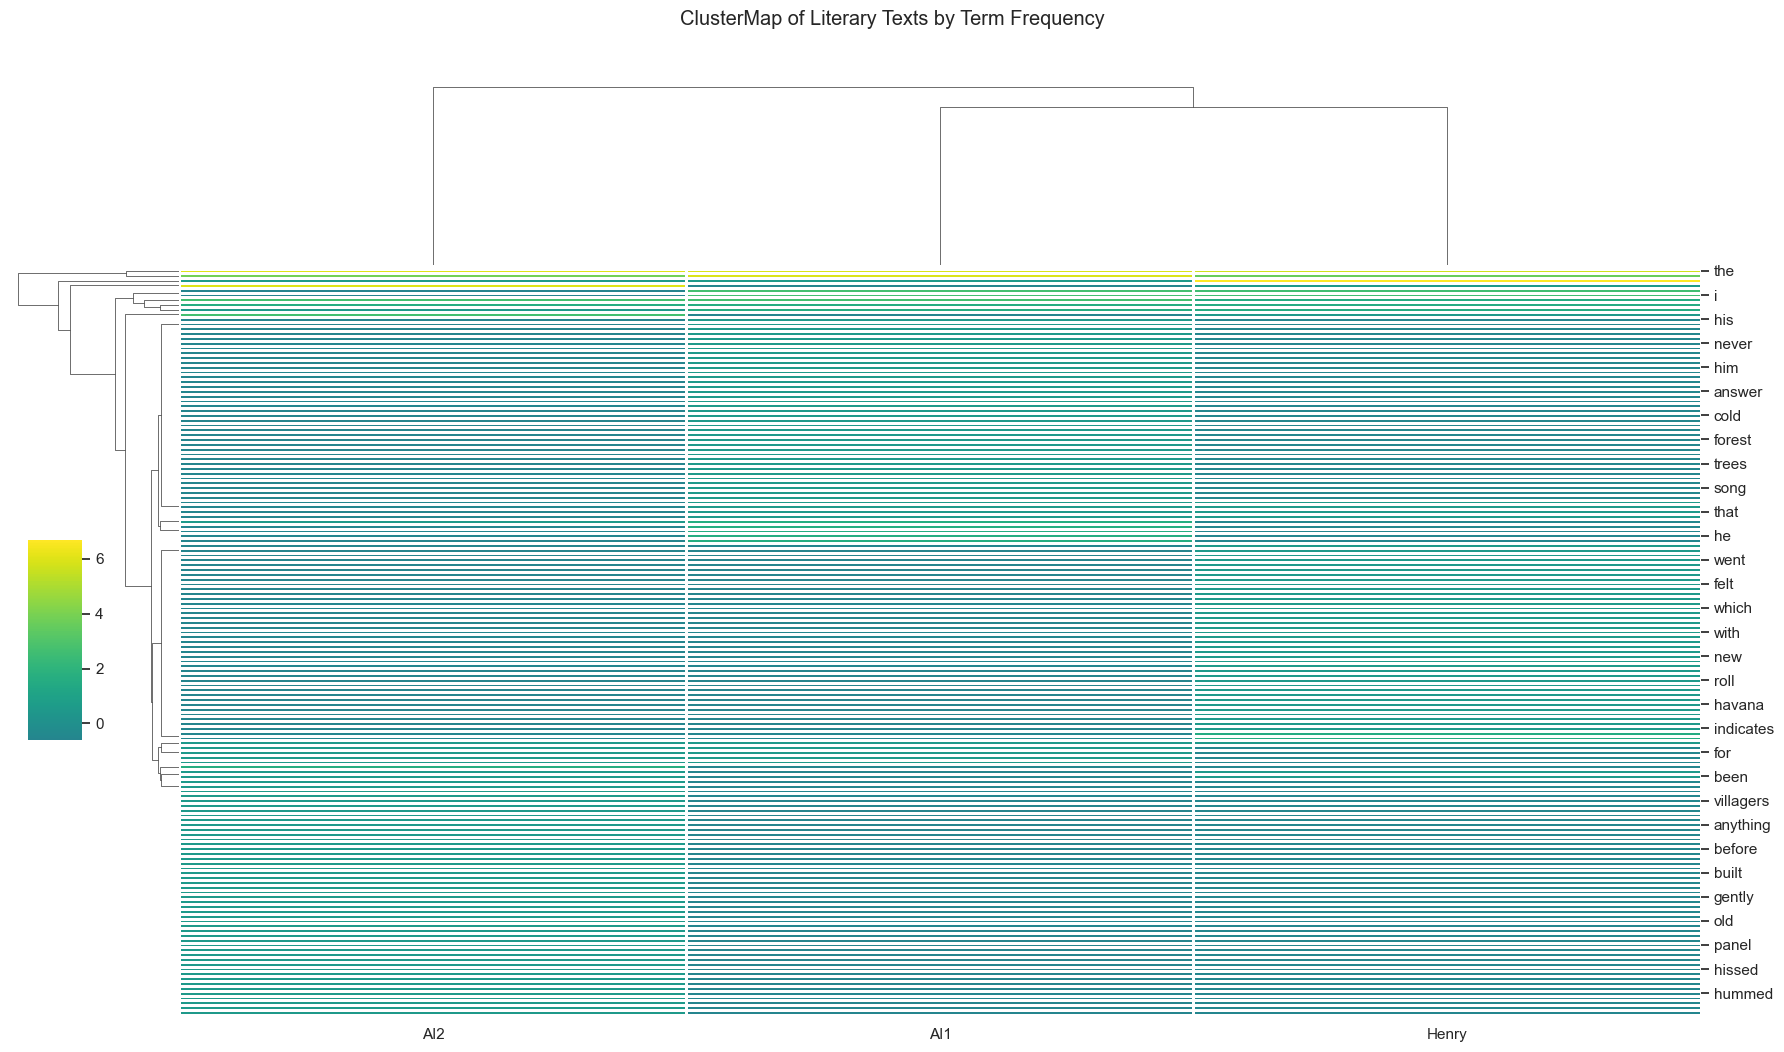

In [13]:
# Cell 11 (Code Cell - MODIFIED to adjust parameters for sparse data)

cm = ClusterMap()

# Generate the ClusterMap.
# Experiment with the parameters below!
fig = cm(
    dtm=dtm_df,
    labels=labels,
    metric="euclidean",   # We keep this as it resolved previous errors
    method="average",
    z_score=1,               # standardize each column (term)s
                          # Later, also try 1 for column-wise scaling
    cmap="viridis",       # <--- CHANGE 2: Try a sequential colormap
    figsize=(18, 10),     # <--- CHANGE 3: Increase figure width to account for many columns
    title="ClusterMap of Literary Texts by Term Frequency",
    hide_upper=False,
    hide_side=False,
    showfig=True,
    # Uncomment and try these for extra insights:
    # col_cluster=False, # Set to False if you want terms in their original order
    # dendrogram_ratio=(0.15, 0.25) # Adjust space for dendrograms
)

### 6. Interpreting Your ClusterMap: Heatmap, Dendrograms, and What They Mean

The ClusterMap provides a wealth of information at a glance. Let's break down how to interpret it:

* **The Heatmap (Center):** This is the core of the ClusterMap. Each cell represents the frequency (or scaled frequency, if you used `z_score` or `standard_scale`) of a particular term in a particular document.
    * **Color Intensity:** The color of each cell indicates the value. With a `vlag` colormap (blue-white-red), blue might represent lower-than-average frequencies, white around average, and red higher-than-average frequencies.
    * **Rows = Documents, Columns = Terms:** Remember that each row is a document and each column is a term.

* **Dendrograms (Side and Top):** These are the tree diagrams that show the clustering.
    * **Left Dendrogram (Documents):** Shows how your documents are grouped based on their shared term usage patterns. Documents that are closer together on this tree are more linguistically similar.
    * **Top Dendrogram (Terms):** Shows how your terms are grouped based on their co-occurrence patterns across documents. Terms that are closer together here tend to appear similarly across your corpus.
    * **Branch Lengths:** As with the BCT, shorter horizontal branches mean greater similarity/closer relationship.

**How to Read the ClusterMap Together:**

1.  **Identify Document Clusters:** Look at the dendrogram on the left. See which documents cluster together.
2.  **Examine Associated Terms:** For a given cluster of documents, look at the corresponding rows in the heatmap. What terms (columns) are particularly "hot" (red) or "cold" (blue) within that cluster? This reveals the vocabulary that defines that group of texts.
3.  **Identify Term Clusters:** Look at the dendrogram on the top. See which terms cluster together.
4.  **Examine Associated Documents:** For a given cluster of terms, look at the corresponding columns in the heatmap. Which documents are particularly "hot" or "cold" for these terms? This helps you understand which texts make characteristic use of certain vocabulary sets.
5.  **Look for Patterns:** Do authors of a certain period cluster together? Do texts from a particular genre show similar term usage patterns? Do specific themes correspond to clusters of terms?

**Example Interpretation (based on typical results for these texts):**

You might find that "Poe_Usher" and "Lippard_Bel" cluster closely, indicating stylistic or thematic similarities. You could then examine the heatmap rows for these documents and see if they have high values (red) for terms related to gothic elements (e.g., "dark", "gloom", "mansion", "ghost"). Conversely, "Irving_Rip" might show lower values for these terms and higher values for words related to nature or folklore.

The ClusterMap allows you to go beyond simple similarity and pinpoint *which specific terms* are driving those similarities and differences.

### 7. Customizing Your Visualization: Making the ClusterMap Your Own

The `lexos` ClusterMap uses `seaborn` and `matplotlib` to create the plot, giving you extensive control over its appearance. You can adjust colors, sizes, titles, and even hide parts of the plot to emphasize your findings.

#### Adjusting Figure Size

The `figsize` parameter in the `ClusterMap` call is critical for making your plot readable, especially with many documents or terms.

```python
# Example of adjusting figsize
# fig = cm(
#     dtm=dtm_df,
#     labels=labels,
#     # ... other parameters ...
#     figsize=(15, 12), # Make it wider and taller
#     showfig=True
# )

### Changing the Color Map (cmap)
Experiment with different colormaps to find one that best highlights your data's patterns.

- Diverging (good for z_score data): "vlag", "coolwarm", "RdBu" (red-blue)
- Sequential (good for raw counts, high to low): "viridis", "plasma", "YlGnBu" (yellow-green-blue)

In [6]:
# Example of changing cmap
# fig = cm(
#     dtm=dtm_df,
#     labels=labels,
#     # ... other parameters ...
#     cmap="viridis", # Change to a sequential colormap
#     showfig=True
# )

### Adding Row/Column Colors

In [7]:
# Example: If 'Poe_Usher' and 'Lippard_Bel' are 'Gothic' and others are 'Adventure'
# Make sure the list of colors matches your 'labels' list in order
# document_categories = ["Gothic", "Gothic", "Adventure", "Adventure", "Adventure", "Adventure"]
# unique_categories = list(set(document_categories))
# color_map = {"Gothic": "purple", "Adventure": "orange"}
# assigned_colors = [color_map[cat] for cat in document_categories]

# fig = cm(
#     dtm=dtm_df,
#     labels=labels,
#     # ... other parameters ...
#     row_colors=assigned_colors, # Use your custom list of colors
#     # Or use a seaborn palette:
#     # row_colors="deep",
#     showfig=True
# )

### Hiding Dendrograms

If you prefer a simpler visual, you can hide the dendrograms.

In [8]:
# Example: Hiding the upper (column) dendrogram
# fig = cm(
#     dtm=dtm_df,
#     labels=labels,
#     # ... other parameters ...
#     hide_upper=True, # Hide the term dendrogram
#     showfig=True
# )